# Image and text loading

In [4]:
import pandas as pd
import os
# First filter the results.csv based on the sampled flickr images
df = pd.read_csv("./data/results.csv", delimiter="|")

def filter_results_csv(images_folder_path, results_df):
    """

    """
    images = []
    for _, _, files in os.walk(images_folder_path):
        for file in files:
            if file.endswith(".jpg"):
                images.append(file)

    results_df = results_df[results_df["image_name"].isin(images)]
    
    return results_df.reset_index(drop=True)

filtered_df = filter_results_csv("./data/flickr_sample/", df)
filtered_df[' comment_number'] = filtered_df[' comment_number'].astype(int)
df_sample = filtered_df[filtered_df[' comment_number'] < 4]
df_sample[['image_name', ' comment']]

,image_name,comment
0,86486817.jpg,A man is vacuuming the rug in a child 's room...
1,86486817.jpg,A man is vacuuming a carpet while a toddler i...
2,86486817.jpg,A grown man is using the vacuum next to a lit...
3,86486817.jpg,A man in a NASCAR hat vacuums while a little ...
5,86497011.jpg,A young boy is beginning to shoot a basketbal...
...,...,...
1493,99804383.jpg,An elderly man sits outside a storefront acco...
1495,998845445.jpg,A man in shorts and a Hawaiian shirt leans ov...
1496,998845445.jpg,"A young man hanging over the side of a boat ,..."
1497,998845445.jpg,A man is leaning off of the side of a blue an...


In [5]:
import json

def dataframe_to_json(df):
    """
    Convert a pandas DataFrame with columns 'image_name' and 'comment'
    into a JSON formatted string, adjusting column names to 'image', 'caption', and 'image_id'.
    
    Args:
    df (pandas.DataFrame): DataFrame containing the data.

    Returns:
    str: A JSON string formatted as specified.
    """
    # Prepare data: rename columns and extract 'image_id' from 'image_name'
    df['image'] = '/export/share/datasets/vision/visual-genome/image/' + df['image_name']
    df['caption'] = df[' comment']
    df['image_id'] = df['image_name'].str.replace('.jpg', '')
    df['dataset'] = 'vg'
    
    # Drop old columns
    df = df[['image', 'caption', 'image_id', 'dataset']]
    
    # Convert DataFrame to dictionary with 'records' orientation
    records = df.to_dict(orient='records')
    
    # Convert the list of dictionaries to a JSON formatted string
    json_output = json.dumps(records, indent=4)  # use indent for pretty printing
    
    return json_output

In [6]:
with open('./vg_caption.json', 'w') as file:
    file.write(dataframe_to_json(df_sample[['image_name', ' comment']]))

In [16]:
/export/share/datasets/vision/visual-genome/image/

C:\Users\tijnv\AppData\Local\Temp\ipykernel_9692\514789190.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['image'] = 'images/' + df['image_name']


'[\n    {\n        "caption": " A man is vacuuming the rug in a child \'s room while a toddler does the same with his toy .",\n        "image": "images/86486817.jpg",\n        "image_id": "86486817"\n    },\n    {\n        "caption": " A young boy is beginning to shoot a basketball as a crowd watches the basketball court .",\n        "image": "images/86497011.jpg",\n        "image_id": "86497011"\n    },\n    {\n        "caption": " Two children are playing ice hockey on frozen ground outside .",\n        "image": "images/86542183.jpg",\n        "image_id": "86542183"\n    },\n    {\n        "caption": " A closeup of a man \'s hand filling up a tin or silver cup with some sort of liquid .",\n        "image": "images/8664920.jpg",\n        "image_id": "8664920"\n    },\n    {\n        "caption": " A married man wearing a watch that appears to be about 7 o\'clock is pouring cream into a coffee type beverage in a blue and white cup .",\n        "image": "images/8664922.jpg",\n        "ima

In [2]:
from PIL import Image
import os
import numpy as np

folder_path = './data/flickr_sample/'

images = {}
images_numpy = {}

for filename in os.listdir(folder_path):
    if filename.endswith(".jpg"):
        images[filename] = Image.open(folder_path + filename)
        images_numpy[filename] = np.array(images[filename])

In [3]:
merged_data = []
for idx, row in df_sample.iterrows():
    image_name = row['image_name']
    if image_name in images:
        image_data = images[image_name]
        merged_data.append({'image_name': image_name, 'comment_number': row[' comment_number'], 'text_input': row[' comment'], 'image': image_data})

# Create a new DataFrame from the merged data
merged_df = pd.DataFrame(merged_data)
dict_input = merged_df[['image', 'text_input']].to_dict("list")

In [4]:
try_out_dict = {'image':dict_input['image'][:3], 'text_input':dict_input['text_input'][:3]} 

In [5]:
# !pip install salesforce-lavis

# Use a fixed image processor and for now 1 image to practice with

In [6]:
# from transformers import ViTImageProcessor

# image_processor, _ = ViTImageProcessor.from_pretrained("nlpconnect/vit-gpt2-image-captioning", return_unused_kwargs=True)

# image_processor

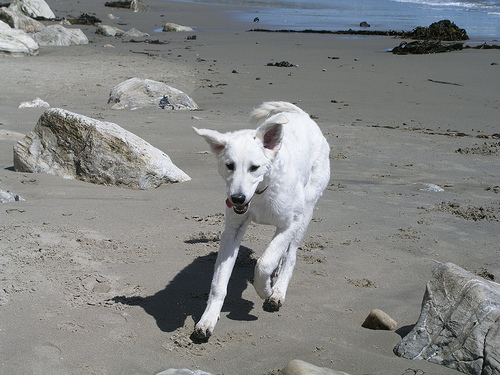

In [7]:
from PIL import Image

example_image = Image.open("./data/flickr_sample/878758390.jpg").convert("RGB")
# processed_image = image_processor(example_image, return_tensors="pt").pixel_values

example_image

In [8]:
# to_pil = transforms.ToPILImage()

# to_pil(processed_image[0])

# Imports

In [9]:
from lavis.models.blip2_models.blip2 import Blip2Base
import torch
import torch.nn as nn
from torch.nn import functional as F
import torch.distributed as dist
from torchvision import transforms
from lavis.models.blip_models.blip_outputs import BlipOutput, BlipOutputFeatures
from lavis.models.base_model import all_gather_with_grad, concat_all_gather

c:\Users\tijnv\Documents\Data Science and Artificial Intelligence\Jaar 2\Master Thesis\Feasibility Study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
IMAGE_DIMENSION = 128

In [11]:
ViT_BLIP2, ViT_LayerNorm = Blip2Base().init_vision_encoder("clip_L", IMAGE_DIMENSION, 0, False, precision='fp32')
print(ViT_BLIP2)

Resizing position embedding grid-size from %s to %s (16, 16) (9, 9)
VisionTransformer(
  (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
  (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  (transformer): Transformer(
    (resblocks): Sequential(
      (0): ResidualAttentionBlock(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
        )
        (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
          (gelu): QuickGELU()
          (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
        )
        (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      )
      (1): ResidualAttentionBlock(
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024,

In [12]:
print(ViT_LayerNorm)

LayerNorm((1024,), eps=1e-05, elementwise_affine=True)


In [13]:
transform =  transforms.Compose([
    transforms.Resize((IMAGE_DIMENSION, IMAGE_DIMENSION)),  # Resize the image
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
])

example_image_torch = transform(example_image)
print(example_image_torch.shape)
example_image_torch = example_image_torch[None, :]
print(example_image_torch.shape)

torch.Size([3, 128, 128])
torch.Size([1, 3, 128, 128])


In [14]:
processed_vit_blip_2_image = ViT_BLIP2(example_image_torch)

In [15]:
LAYER_NORM_DIM = processed_vit_blip_2_image.shape[2]

In [16]:
class IdentityModel(nn.Module):
    def __init__(self):
        super(IdentityModel, self).__init__()

    def forward(self, x):
        return x

In [17]:
class PathologyBlipQformer(Blip2Base):
    """
    BLIP2 first-stage model with Q-Former and already processed image data.

    """
    def __init__(
        self,
        vit_model = IdentityModel(),
        img_shape: int = LAYER_NORM_DIM, # Assuming this is either (x, y, z) shaped or (x, ) shaped
        freeze_vit: bool = True,
        num_query_token: int = 8,
        cross_attention_freq: int = 2,
        embed_dim: int = 128,
        max_txt_len=128,
    ):
        super().__init__()

        self.tokenizer = self.init_tokenizer()

        self.visual_encoder = vit_model

        self.ln_vision = nn.LayerNorm(img_shape) #@TODO This should be altered to match something of HIPT's shape
                                                      # but for now, we will use this default value

        self.Qformer, self.query_tokens = self.init_Qformer(
            num_query_token, img_shape, cross_attention_freq
        )

        self.Qformer.resize_token_embeddings(len(self.tokenizer))
        state_dict = self.Qformer.state_dict()
        for name, param in self.Qformer.named_parameters(): # Something is altered to enhance shared weights accross layers
            if "_query" in name:
                key_orig = name.replace("_query", "")
                param.data.copy_(state_dict[key_orig])

        self.vision_proj = nn.Linear(self.Qformer.config.hidden_size, embed_dim)
        self.text_proj = nn.Linear(self.Qformer.config.hidden_size, embed_dim)

        self.itm_head = nn.Linear(self.Qformer.config.hidden_size, 2)

        self.temp = nn.Parameter(0.07 * torch.ones([]))

        self.max_txt_len = max_txt_len

    def forward(self, samples):
        image = samples["image"]
        text = samples["text_input"]

        image_embeds = self.ln_vision(self.visual_encoder(image))
        image_atts = torch.ones(image_embeds.size()[:-1], dtype=torch.long).to(
            image.device
        )

        query_tokens = self.query_tokens.expand(image_embeds.shape[0], -1, -1)

        query_output = self.Qformer.bert(
            query_embeds=query_tokens,
            encoder_hidden_states=image_embeds,
            encoder_attention_mask=image_atts,
            use_cache=True,
            return_dict=True,
        )

        image_feats = F.normalize(
            self.vision_proj(query_output.last_hidden_state), dim=-1
        )

        text_tokens = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_txt_len,
            return_tensors="pt",
        ).to(image.device)
        text_output = self.Qformer.bert(
            text_tokens.input_ids,
            attention_mask=text_tokens.attention_mask,
            return_dict=True,
        )
        text_feat = F.normalize(
            self.text_proj(text_output.last_hidden_state[:, 0, :]), dim=-1
        )

        ###============== Image-text Contrastive ===================###
        image_feats_all = concat_all_gather(
            image_feats
        )  # [batch_size*num_gpu, num_query_tokens, embed_dim]
        text_feat_all = concat_all_gather(text_feat)  # [batch_size*num_gpu, embed_dim]

        sim_q2t = torch.matmul(
            image_feats.unsqueeze(1), text_feat_all.unsqueeze(-1)
        ).squeeze()
        # [batch_size, batch_size*num_gpu, num_query_tokens]

        # image-text similarity: aggregate across all query tokens
        sim_i2t, _ = sim_q2t.max(-1)
        sim_i2t = sim_i2t / self.temp

        # text-query similarity: [batch_size, batch_size*num_gpu, num_query_tokens]
        sim_t2q = torch.matmul(
            text_feat.unsqueeze(1).unsqueeze(1), image_feats_all.permute(0, 2, 1)
        ).squeeze()

        # text-image similarity: aggregate across all query tokens
        sim_t2i, _ = sim_t2q.max(-1)
        sim_t2i = sim_t2i / self.temp  # [batch_size, batch_size*num_gpu]

        bs = image.size(0)
        targets = torch.linspace(0, bs - 1, bs, dtype=int).to(
            image.device
        )

        if "image_id" in samples.keys(): #coco retrieval finetuning
            image_ids = samples["image_id"].view(-1,1)
            image_ids_all = concat_all_gather(image_ids)
            pos_idx = torch.eq(image_ids, image_ids_all.t()).float()       
            sim_targets = pos_idx / pos_idx.sum(1,keepdim=True)   
            sim_targets = 0.9 * sim_targets + 0.1 * torch.ones_like(sim_targets) / sim_targets.size(1)

            loss_t2i = -torch.sum(F.log_softmax(sim_t2i, dim=1)*sim_targets,dim=1).mean()
            loss_i2t = -torch.sum(F.log_softmax(sim_i2t, dim=1)*sim_targets,dim=1).mean()     
            loss_itc = (loss_t2i+loss_i2t)/2  
        else:                     
            loss_itc = (
                F.cross_entropy(sim_i2t, targets, label_smoothing=0.1)
                + F.cross_entropy(sim_t2i, targets, label_smoothing=0.1)
            ) / 2

        ###============== Image-text Matching ===================###
        text_input_ids_world = concat_all_gather(text_tokens.input_ids)
        text_attention_mask_world = concat_all_gather(text_tokens.attention_mask)
        # image_embeds_world = all_gather_with_grad(image_embeds)
        image_embeds_world = image_embeds

        with torch.no_grad():
            if "image_id" in samples.keys():
                mask = torch.eq(image_ids, image_ids_all.t())
                sim_t2i.masked_fill_(mask, -10000)
                sim_i2t.masked_fill_(mask, -10000)
            else:    
                sim_t2i[:, bs : bs + bs].fill_diagonal_(-10000)
                sim_i2t[:, bs : bs + bs].fill_diagonal_(-10000)            
                
            weights_t2i = F.softmax(sim_t2i, dim=1)
            weights_i2t = F.softmax(sim_i2t, dim=1)

        # select a negative image for each text
        image_embeds_neg = []
        for b in range(bs):
            neg_idx = torch.multinomial(weights_t2i[b], 1).item()
            image_embeds_neg.append(image_embeds_world[neg_idx])
        image_embeds_neg = torch.stack(image_embeds_neg, dim=0)

        # select a negative text for each image
        text_ids_neg = []
        text_atts_neg = []
        for b in range(bs):
            neg_idx = torch.multinomial(weights_i2t[b], 1).item()
            text_ids_neg.append(text_input_ids_world[neg_idx])
            text_atts_neg.append(text_attention_mask_world[neg_idx])

        text_ids_neg = torch.stack(text_ids_neg, dim=0)
        text_atts_neg = torch.stack(text_atts_neg, dim=0)

        text_ids_all = torch.cat(
            [text_tokens.input_ids, text_tokens.input_ids, text_ids_neg], dim=0
        )  # pos, pos, neg
        text_atts_all = torch.cat(
            [text_tokens.attention_mask, text_tokens.attention_mask, text_atts_neg],
            dim=0,
        )

        query_tokens_itm = self.query_tokens.expand(text_ids_all.shape[0], -1, -1)
        query_atts_itm = torch.ones(query_tokens_itm.size()[:-1], dtype=torch.long).to(
            image.device
        )
        attention_mask_all = torch.cat([query_atts_itm, text_atts_all], dim=1)

        image_embeds_all = torch.cat(
            [image_embeds, image_embeds_neg, image_embeds], dim=0
        )  # pos, neg, pos
        image_atts_all = torch.ones(image_embeds_all.size()[:-1], dtype=torch.long).to(
            image.device
        )

        output_itm = self.Qformer.bert(
            text_ids_all,
            query_embeds=query_tokens_itm,
            attention_mask=attention_mask_all,
            encoder_hidden_states=image_embeds_all,
            encoder_attention_mask=image_atts_all,
            return_dict=True,
        )

        vl_embeddings = output_itm.last_hidden_state[:, : query_tokens_itm.size(1), :]
        vl_output = self.itm_head(vl_embeddings)
        logits = vl_output.mean(dim=1)

        itm_labels = torch.cat(
            [torch.ones(bs, dtype=torch.long), torch.zeros(2 * bs, dtype=torch.long)],
            dim=0,
        ).to(image.device)
        loss_itm = F.cross_entropy(logits, itm_labels)

        ##================= Image Captioning ========================##
        decoder_input_ids = text_tokens.input_ids.clone()
        decoder_input_ids[:, 0] = self.tokenizer.bos_token_id
        labels = decoder_input_ids.masked_fill(
            decoder_input_ids == self.tokenizer.pad_token_id, -100
        )

        query_atts = torch.ones(query_tokens.size()[:-1], dtype=torch.long).to(
            image.device
        )
        attention_mask = torch.cat([query_atts, text_tokens.attention_mask], dim=1)
        lm_output = self.Qformer(
            decoder_input_ids,
            attention_mask=attention_mask,
            past_key_values=query_output.past_key_values,
            return_dict=True,
            labels=labels,
        )

        loss_lm = lm_output.loss

        return BlipOutput(
            loss=loss_itc + loss_itm + loss_lm,
            loss_itc=loss_itc,
            loss_itm=loss_itm,
            loss_lm=loss_lm,
        )
    
PathBlipQF = PathologyBlipQformer()

In [18]:
transformed_tensors = []

# Apply transformation to each image and store the resulting tensor
for img in try_out_dict['image']:
    transformed_img = transform(img)  # Apply transformation
    transformed_tensors.append(transformed_img)

# Stack the transformed tensors along a new dimension to create a single tensor
stacked_tensor = torch.stack(transformed_tensors, dim=0)

print(stacked_tensor.shape)

ViT_tensor = ViT_BLIP2(stacked_tensor)
try_out_dict['image'] = ViT_tensor

torch.Size([3, 3, 128, 128])


In [28]:
try_out_dict['text_input']

[" A man is vacuuming the rug in a child 's room while a toddler does the same with his toy .",
 ' A young boy is beginning to shoot a basketball as a crowd watches the basketball court .',
 ' Two children are playing ice hockey on frozen ground outside .']

In [20]:
loss = PathBlipQF.forward(try_out_dict)

In [25]:
loss

BlipOutput(sims=None, intermediate_output=None, loss=tensor(11.2923, grad_fn=<AddBackward0>), loss_itc=tensor(1.1563, grad_fn=<DivBackward0>), loss_itm=tensor(0.6729, grad_fn=<NllLossBackward0>), loss_lm=tensor(9.4631, grad_fn=<AddBackward0>))

In [ ]:
# Training loop
for epoch in range(num_epochs):
    # Iterate over batches
    for batch in dataloader:
        # Clear gradients
        optimizer.zero_grad()
        
        # Forward pass
        inputs, labels = batch
        outputs = model(inputs)
        
        # Compute loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
